# Smartphone Classification

#Reads the dataset from a CSV file.
#Cleans column names and removes missing values.
#Converts RAM, Battery Capacity, and Price columns into numerical values.
## Data Visualization:
#Creates a bar chart showing the distribution of phone brands.
#Plots different visualizations for RAM, Battery Capacity, Screen Size, and Camera distributions.
#Generates a correlation heatmap to understand relationships between features. 
## Training and Testing Machine Learning Models:
#Uses 5 different ML models (Logistic Regression, Random Forest, SVM, Decision Tree, KNN) to classify phones as expensive or affordable.
#Evaluates model accuracy and visualizes the results with a bar chart. ## Training and Testing Deep Learning Models:
#Implements Artificial Neural Networks (ANNs) with 3 different architectures (Simple, Normal, Complex).
#Trains and tests the models to predict phone price categories.
#Visualizes accuracy results using a bar chart.


In [5]:

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')
%matplotlib inline

In [6]:
data =pd.read_csv('Mobiles Dataset (2025).csv',encoding="latin1")

In [7]:
data

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,Poco,Pad 5G 128GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 66,220","INR 23,999","CNY 2,099",USD 280,"AED 1,029",2024
926,Poco,Pad 5G 256GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 71,220","INR 25,999","CNY 2,299",USD 300,"AED 1,099",2024
927,Samsung,Galaxy Z Fold6 256GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 604,999","INR 164,999","¥13,999","USD 1,899","AED 7,199",2024
928,Samsung,Galaxy Z Fold6 512GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 544,999","INR 176,999","CNY 15,999",USD 1719,"AED 7,699",2024


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Name               930 non-null    object
 1   Model Name                 930 non-null    object
 2   Mobile Weight              930 non-null    object
 3   RAM                        930 non-null    object
 4   Front Camera               930 non-null    object
 5   Back Camera                930 non-null    object
 6   Processor                  930 non-null    object
 7   Battery Capacity           930 non-null    object
 8   Screen Size                930 non-null    object
 9   Launched Price (Pakistan)  930 non-null    object
 10  Launched Price (India)     930 non-null    object
 11  Launched Price (China)     930 non-null    object
 12  Launched Price (USA)       930 non-null    object
 13  Launched Price (Dubai)     930 non-null    object
 14  Launched Y

In [9]:
data.describe(include='all')

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
count,930,930,930,930,930,930,930,930,930,930,930,930,930,930,930.000000
unique,19,908,148,11,29,91,217,147,97,157,147,137,107,141,NaN
top,Oppo,Pad 128GB,190g,8GB,16MP,50MP,Snapdragon 8 Gen 2,"5,000mAh",6.7 inches,"PKR 79,999","INR 29,999","CNY 2,499",USD 499,"AED 1,499",NaN
freq,129,3,68,308,211,182,30,197,124,39,35,36,44,39,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.193548
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.862080
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000


In [10]:
data.shape

(930, 15)

In [11]:
df1=data.dropna()

In [12]:
df1

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,Poco,Pad 5G 128GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 66,220","INR 23,999","CNY 2,099",USD 280,"AED 1,029",2024
926,Poco,Pad 5G 256GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 71,220","INR 25,999","CNY 2,299",USD 300,"AED 1,099",2024
927,Samsung,Galaxy Z Fold6 256GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 604,999","INR 164,999","¥13,999","USD 1,899","AED 7,199",2024
928,Samsung,Galaxy Z Fold6 512GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 544,999","INR 176,999","CNY 15,999",USD 1719,"AED 7,699",2024


In [13]:
df1.shape

(930, 15)

In [14]:

def eda(file_path):
    df=df1
    df.coloumns = df.columns.str.strip()
    df=df.dropna()

    def clean_ram(value):
        numbers= re.findall(r'\d+',str(value)) #extract all number
        numbers = list(map(int,numbers)) # convert to integers
        return sum(numbers)/len(numbers) if numbers else None #take the 

    df['RAM']= df['RAM'].astype(str).apply(clean_ram).astype(float)
    df['Battery Capacity']=df['Battery Capacity'].astype(str).str.replace(',', '').str.extract(r'(\d+)')[0].astype(float)
    df['Price']=df['Launched Price (USA)'].astype(str).str.extract(r'(\d+)')[0].astype(float)

    return df
file_path= df1
df=eda(file_path)


In [15]:
df

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year,Price
0,Apple,iPhone 16 128GB,174g,6.0,12MP,48MP,A17 Bionic,3600.0,6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024,799.0
1,Apple,iPhone 16 256GB,174g,6.0,12MP,48MP,A17 Bionic,3600.0,6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024,849.0
2,Apple,iPhone 16 512GB,174g,6.0,12MP,48MP,A17 Bionic,3600.0,6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024,899.0
3,Apple,iPhone 16 Plus 128GB,203g,6.0,12MP,48MP,A17 Bionic,4200.0,6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024,899.0
4,Apple,iPhone 16 Plus 256GB,203g,6.0,12MP,48MP,A17 Bionic,4200.0,6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024,949.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,Poco,Pad 5G 128GB,571g,8.0,8MP,8MP,Snapdragon 7s Gen 2,10000.0,12.1 inches,"PKR 66,220","INR 23,999","CNY 2,099",USD 280,"AED 1,029",2024,280.0
926,Poco,Pad 5G 256GB,571g,8.0,8MP,8MP,Snapdragon 7s Gen 2,10000.0,12.1 inches,"PKR 71,220","INR 25,999","CNY 2,299",USD 300,"AED 1,099",2024,300.0
927,Samsung,Galaxy Z Fold6 256GB,239g,12.0,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400.0,7.6 inches,"PKR 604,999","INR 164,999","¥13,999","USD 1,899","AED 7,199",2024,1.0
928,Samsung,Galaxy Z Fold6 512GB,239g,12.0,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400.0,7.6 inches,"PKR 544,999","INR 176,999","CNY 15,999",USD 1719,"AED 7,699",2024,1719.0


In [16]:
df.shape

(930, 16)

# Visualize the data

In [17]:

import seaborn as sns
def visual(df):
    plt.figure(figsize=(12,6))
    df['Company Name'].value_counts().plot(kind='bar',title='Phone distribution')
    plt.show()

    plt.figure(figsize=(12,6))
    sns.histplot(df['RAM'],bins=10,kde=True)
    plt.title('Ram distribution')
    plt.show()

    
#additional 18 plots(scatter ,bar,boxplots,heatmaps etc)
    for col in ['Front Camera','Back Camera','Battery Capacity','Screen Size']:
        df[col] = df[col].astype(str).str.extract(r'(\d+)')[0].astype(float)
        plt.figure(figsize=(12,6))
        sns.boxplot(x=df[col])
        plt.title(f'Distribution of{col}')
        plt.show()

#correlation heatmap
    plt.figure(figsize=(12,6))
    df_corr=df.select_dtypes(include =[np.number])
    sns.heatmap(df_corr.corr(),annot=True, cmap='coolwarm',fmt='.2f')
    plt.title('Feature correclatiob Matrix')
    plt.show()

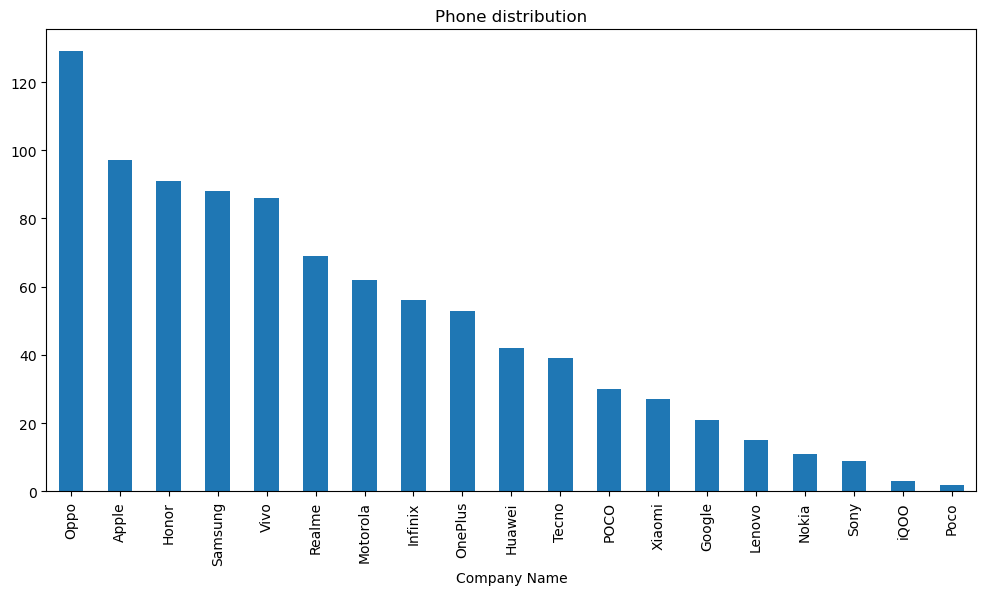

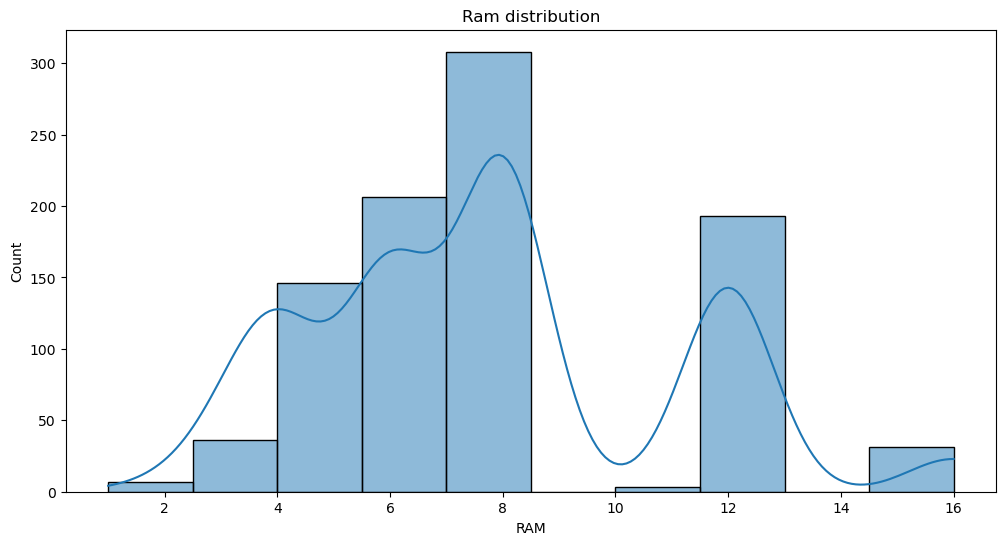

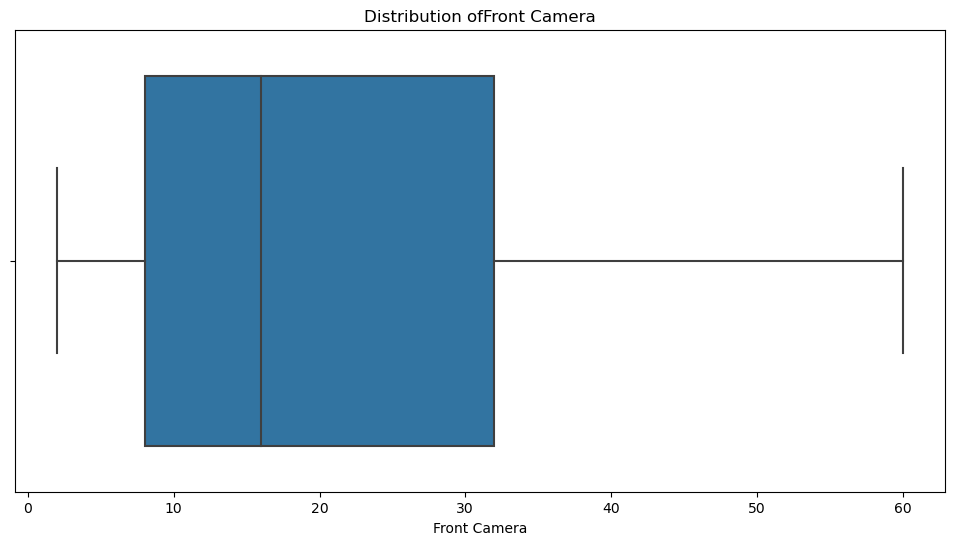

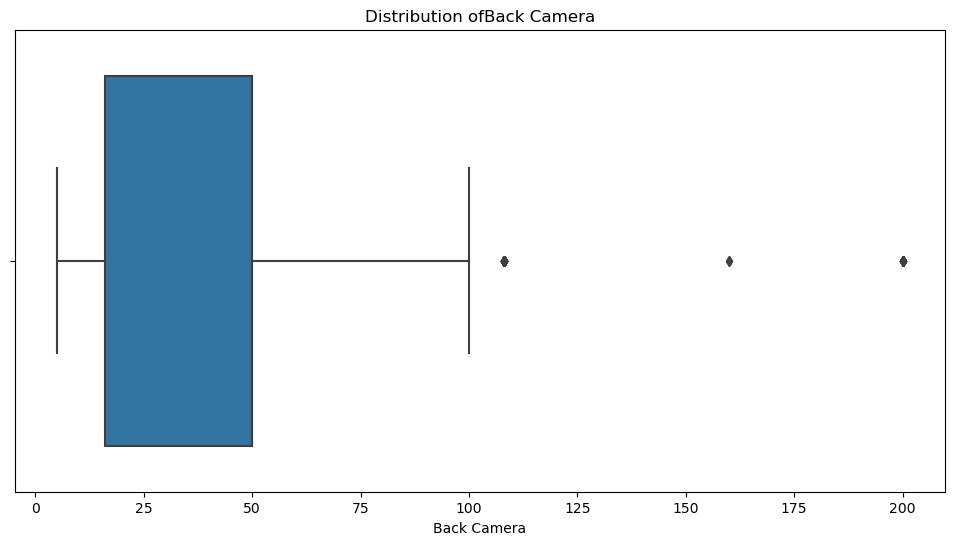

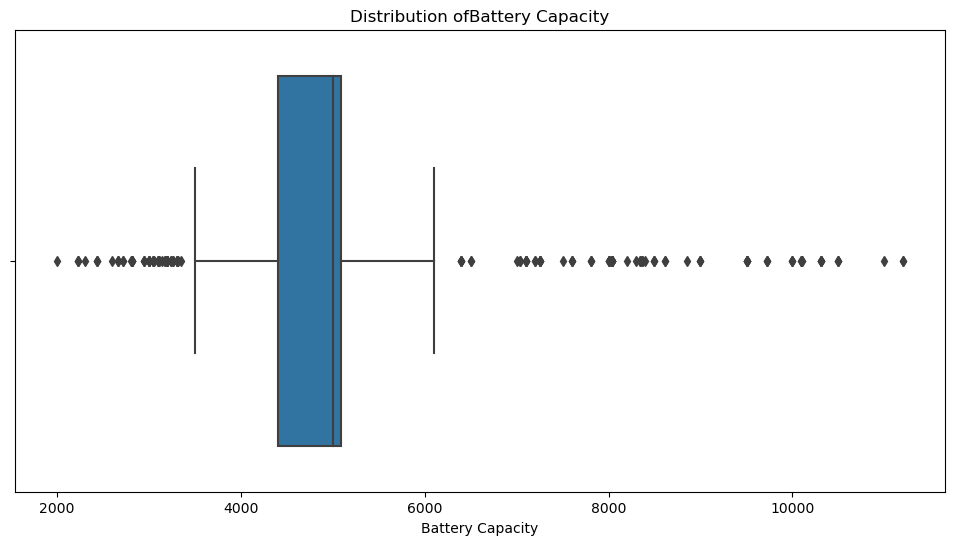

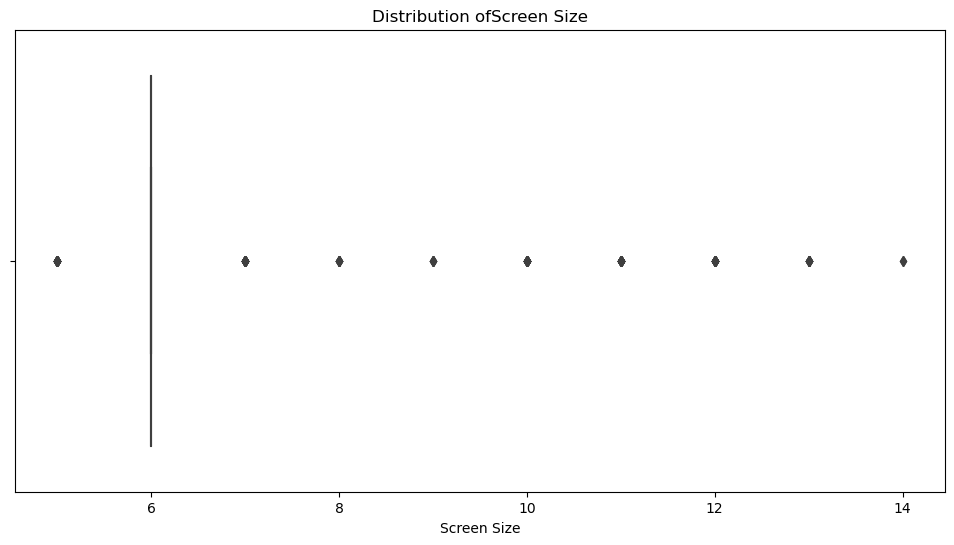

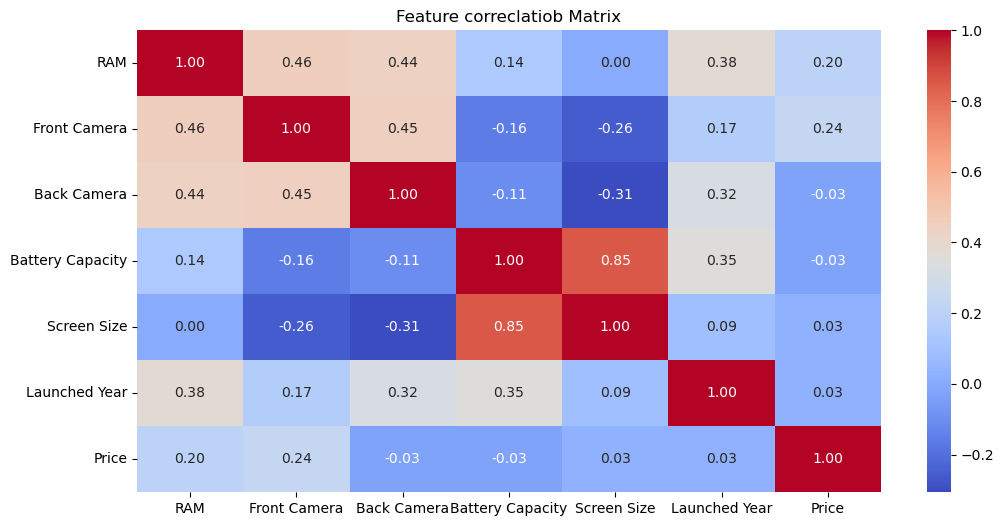

In [18]:
visual(df)

# Macine learning models

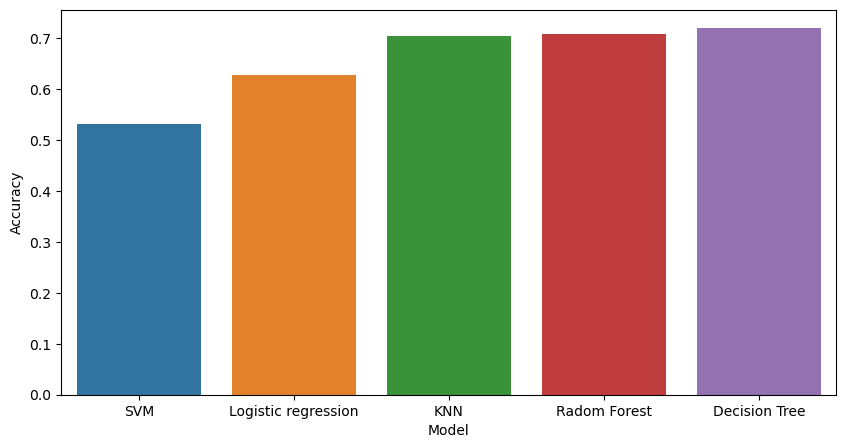

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

def ml_model(df):
    X= df[['RAM','Battery Capacity']]
    y= df['Price']>df['Price'].median()
    
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2 ,random_state=42)

    models={
        'Logistic regression': LogisticRegression(),
        'Radom Forest': RandomForestClassifier(),
        'SVM': SVC(),
        'Decision Tree': DecisionTreeClassifier(),
        'KNN': KNeighborsClassifier()
        }
    results= {}
    for name,model in models.items():
        model.fit(X_train,y_train)
        y_pred= model.predict(X_test)
        acc=accuracy_score(y_test,y_pred)
        results[name]= acc

    results_df= pd.DataFrame(list(results.items()),columns=['Model','Accuracy'])
    results_df.sort_values(by='Accuracy',ascending=True,inplace=True)

    plt.figure(figsize=(10,5))
    sns.barplot(x='Model',y='Accuracy',data=results_df)
    plt.show()

    return results_df

ml_results=ml_model(df)

In [20]:
# Deep Learning Approach

In [21]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [22]:
def train_dl_models(df):
    X = df[['RAM', 'Battery Capacity']]
    y = df['Price'] > df['Price'].median()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    def build_ann(layers, activation='relu'):
        model = Sequential()
        for i, nodes in enumerate(layers):
            if i == 0:
                model.add(Dense(nodes, activation=activation, input_shape=(X_train.shape[1],)))
            else:
                model.add(Dense(nodes, activation=activation))
            if i < len(layers) - 1:
                model.add(Dropout(0.2))
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return model
    
    ann_types = {
        'Simple': [8, 4],
        'Normal': [16, 8, 4],
        'Complex': [32, 16, 8]
    }
    
    dl_results = {}
    for name, layers in ann_types.items():
        model = build_ann(layers)
        model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)
        _, acc = model.evaluate(X_test, y_test, verbose=0)
        dl_results[name] = acc
    
    dl_results_df = pd.DataFrame(list(dl_results.items()), columns=['Model', 'Accuracy'])
    dl_results_df.sort_values(by='Accuracy', ascending=False, inplace=True)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Model', y='Accuracy', data=dl_results_df)
    plt.title("DL Model Accuracies")
    plt.show()
    
    return dl_results_df

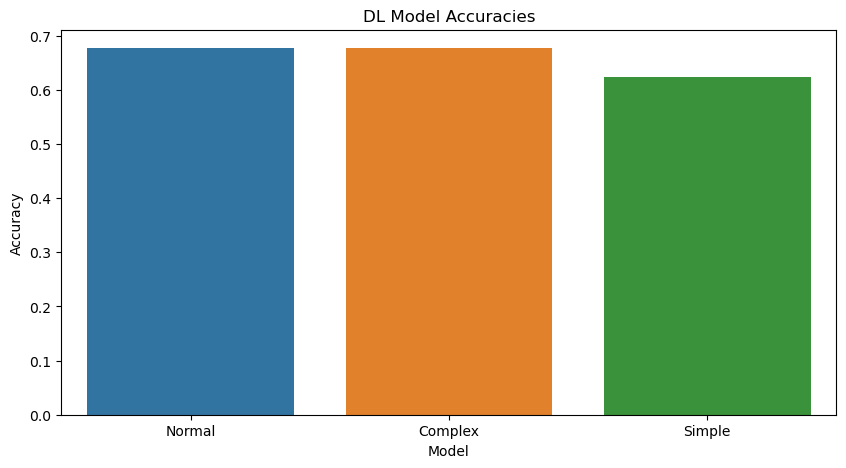

In [23]:
dl_results = train_dl_models(df)

In [ ]:
Reads the dataset from a CSV file.
Cleans column names and removes missing values.
Converts RAM, Battery Capacity, and Price columns into numerical values. ## Data Visualization:
Creates a bar chart showing the distribution of phone brands.
Plots different visualizations for RAM, Battery Capacity, Screen Size, and Camera distributions.
Generates a correlation heatmap to understand relationships between features. ## Training and Testing Machine Learning Models:
Uses 5 different ML models (Logistic Regression, Random Forest, SVM, Decision Tree, KNN) to classify phones as expensive or affordable.
Evaluates model accuracy and visualizes the results with a bar chart. ## Training and Testing Deep Learning Models:
Implements Artificial Neural Networks (ANNs) with 3 different architectures (Simple, Normal, Complex).
Trains and tests the models to predict phone price categories.
Visualizes accuracy results using a bar chart.